# Module 2 — Clinical Structural Preprocessing & ROI Extraction (v2)

## Objective
Process raw clinical images by isolating the subject, detecting the arm region,
and measuring the Mid-Upper Arm Circumference (MUAC) proxy in pixels — working
reliably for **both half-sleeve and full-sleeve clothing**.

## Architecture
1. **Semantic Isolation** — YOLOv8 removes background noise
2. **Skeletal Anchoring** — MediaPipe Pose detects shoulder/elbow landmarks
3. **Sleeve Detection** — Checks wrist visibility to decide measurement mode
4. **Dual-Mode Measurement**
   - `SKIN mode` — wrist visible → ray-cast to skin/fabric boundary (high confidence)
   - `SLEEVE mode` — wrist hidden → ray-cast to outer sleeve boundary + correction factor
5. **Output A** — Full-body 224×224 tensor for CNN path
6. **Output B** — Annotated arm crop with MUAC pixel measurement


In [8]:
!pip install ultralytics mediapipe opencv-python numpy matplotlib pillow



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import logging
import warnings
from pathlib import Path
from ultralytics import YOLO
import mediapipe as mp

warnings.filterwarnings("ignore")
logging.getLogger("ultralytics").setLevel(logging.ERROR)

print("✓ Dependencies loaded successfully.")


✓ Dependencies loaded successfully.


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import logging
import warnings
from pathlib import Path
from ultralytics import YOLO
import mediapipe as mp

warnings.filterwarnings("ignore")
logging.getLogger("ultralytics").setLevel(logging.ERROR)


class NutriVisionStage2:

    SLEEVE_CORRECTION_CENTER = 0.92
    SLEEVE_CORRECTION_TIGHT  = 0.96
    SLEEVE_CORRECTION_LOOSE  = 0.85
    MUAC_POSITION_RATIO      = 0.40

    def __init__(self, target_size=(224, 224)):
        print("INFO: Initializing NutriVision Stage 2 Pipeline...")
        self.target_size = target_size
        self.yolo        = YOLO("yolo11x-seg.pt")
        self.mp_pose     = mp.solutions.pose
        self.pose        = self.mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)
        print("INFO: Pipeline ready.\n")

    def _isolate_subject(self, image_bgr):
        results = self.yolo(image_bgr, verbose=False, retina_masks=True, imgsz=1024)
        mask_8u = np.zeros(image_bgr.shape[:2], dtype=np.uint8)
        if results[0].masks is None or results[0].boxes is None:
            print("  WARN: YOLO found no person. Using full image.")
            mask_8u[:] = 255
            return image_bgr.copy(), mask_8u
        largest_area = 0
        best_polygon = None
        for i, box in enumerate(results[0].boxes):
            if int(box.cls[0]) == 0:
                polygon = results[0].masks.xy[i]
                area    = cv2.contourArea(np.array(polygon, dtype=np.float32))
                if area > largest_area:
                    largest_area = area
                    best_polygon = polygon
        if best_polygon is not None:
            cv2.fillPoly(mask_8u, [np.int32(best_polygon)], 255)
        else:
            mask_8u[:] = 255
        mask_8u = cv2.GaussianBlur(mask_8u, (5, 5), 0)
        _, mask_8u = cv2.threshold(mask_8u, 127, 255, cv2.THRESH_BINARY)
        cleaned = np.where(mask_8u[..., None] > 0, image_bgr, 0)
        return cleaned, mask_8u

    def _pad_to_square(self, image_bgr):
        h, w = image_bgr.shape[:2]
        if h == 0 or w == 0:
            return np.zeros((*self.target_size, 3), dtype=np.uint8)
        th, tw = self.target_size
        scale  = min(tw / w, th / h)
        nw, nh = int(w * scale), int(h * scale)
        resized = cv2.resize(image_bgr, (nw, nh), interpolation=cv2.INTER_CUBIC)
        padded  = np.zeros((th, tw, 3), dtype=np.uint8)
        y_off   = (th - nh) // 2
        x_off   = (tw - nw) // 2
        padded[y_off:y_off+nh, x_off:x_off+nw] = resized
        return padded

    def _get_full_body_tensor(self, cleaned_image, mask_8u):
        coords = cv2.findNonZero(mask_8u)
        if coords is not None:
            x, y, w, h = cv2.boundingRect(coords)
            buf = int(max(w, h) * 0.02)
            x0  = max(0, x - buf)
            y0  = max(0, y - buf)
            x1  = min(cleaned_image.shape[1], x + w + buf)
            y1  = min(cleaned_image.shape[0], y + h + buf)
            cropped = cleaned_image[y0:y1, x0:x1]
        else:
            cropped = cleaned_image
        return self._pad_to_square(cropped)

    def _get_pose_landmarks(self, cleaned_bgr):
        rgb     = cv2.cvtColor(cleaned_bgr, cv2.COLOR_BGR2RGB)
        results = self.pose.process(rgb)
        return results.pose_landmarks

    def _get_best_arm(self, landmarks, w, h):
        LM = self.mp_pose.PoseLandmark

        def px(lm):
            return (int(lm.x * w), int(lm.y * h))

        lsh = landmarks.landmark[LM.LEFT_SHOULDER.value]
        lel = landmarks.landmark[LM.LEFT_ELBOW.value]
        lwr = landmarks.landmark[LM.LEFT_WRIST.value]
        rsh = landmarks.landmark[LM.RIGHT_SHOULDER.value]
        rel = landmarks.landmark[LM.RIGHT_ELBOW.value]
        rwr = landmarks.landmark[LM.RIGHT_WRIST.value]

        left_ok  = lsh.visibility > 0.4 and lel.visibility > 0.4
        right_ok = rsh.visibility > 0.4 and rel.visibility > 0.4

        if left_ok and (not right_ok or (lsh.visibility + lel.visibility) >= (rsh.visibility + rel.visibility)):
            return dict(side='left',  shoulder=px(lsh), elbow=px(lel),
                        wrist=px(lwr), wrist_visible=lwr.visibility > 0.5,
                        wrist_vis=lwr.visibility)
        elif right_ok:
            return dict(side='right', shoulder=px(rsh), elbow=px(rel),
                        wrist=px(rwr), wrist_visible=rwr.visibility > 0.5,
                        wrist_vis=rwr.visibility)
        return None

    def _skin_mode_measure(self, cleaned_bgr, arm):
        sx, sy = arm['shoulder']
        ex, ey = arm['elbow']
        h, w   = cleaned_bgr.shape[:2]
        dx     = ex - sx
        dy     = ey - sy
        mag    = math.sqrt(dx**2 + dy**2)
        if mag == 0:
            return None
        ux = -dy / mag
        uy =  dx / mag
        mid_x = int(sx + dx * self.MUAC_POSITION_RATIO)
        mid_y = int(sy + dy * self.MUAC_POSITION_RATIO)
        gray           = cv2.cvtColor(cleaned_bgr, cv2.COLOR_BGR2GRAY)
        _, binary_mask = cv2.threshold(gray, 15, 1, cv2.THRESH_BINARY)
        blurred        = cv2.GaussianBlur(gray, (5, 5), 0)
        edges          = cv2.Canny(blurred, 20, 80)

        def cast(step_x, step_y):
            cx, cy    = float(mid_x), float(mid_y)
            max_steps = int(mag * 0.8)
            steps     = 0
            while 0 < int(cy) < h and 0 < int(cx) < w and steps < max_steps:
                icy, icx = int(cy), int(cx)
                if binary_mask[icy, icx] == 0:
                    break
                if steps > 5 and edges[icy, icx] != 0:
                    break
                cx += step_x
                cy += step_y
                steps += 1
            return int(cx), int(cy)

        pt1       = cast( ux,  uy)
        pt2       = cast(-ux, -uy)
        width_px  = math.sqrt((pt2[0]-pt1[0])**2 + (pt2[1]-pt1[1])**2)
        circum_px = width_px * math.pi

        return dict(
            pt1=pt1, pt2=pt2, mid_pt=(mid_x, mid_y),
            width_px=width_px, circumference_px=circum_px,
            mode='SKIN', confidence=0.90,
            correction_range=(width_px, width_px),
            raw_sleeve_px=None,
            edges=edges, shoulder=(sx, sy), elbow=(ex, ey)
        )

    def _sleeve_mode_measure(self, cleaned_bgr, arm):
        sx, sy = arm['shoulder']
        ex, ey = arm['elbow']
        h, w   = cleaned_bgr.shape[:2]
        dx     = ex - sx
        dy     = ey - sy
        mag    = math.sqrt(dx**2 + dy**2)
        if mag == 0:
            return None
        ux = -dy / mag
        uy =  dx / mag
        mid_x = int(sx + dx * self.MUAC_POSITION_RATIO)
        mid_y = int(sy + dy * self.MUAC_POSITION_RATIO)
        gray           = cv2.cvtColor(cleaned_bgr, cv2.COLOR_BGR2GRAY)
        _, binary_mask = cv2.threshold(gray, 15, 1, cv2.THRESH_BINARY)
        blurred_heavy  = cv2.GaussianBlur(gray, (9, 9), 0)
        edges_vis      = cv2.Canny(blurred_heavy, 30, 90)

        def cast_to_background(step_x, step_y):
            cx, cy    = float(mid_x), float(mid_y)
            max_steps = int(mag * 0.9)
            steps     = 0
            while 0 < int(cy) < h and 0 < int(cx) < w and steps < max_steps:
                if binary_mask[int(cy), int(cx)] == 0:
                    break
                cx += step_x
                cy += step_y
                steps += 1
            return int(cx), int(cy)

        pt1           = cast_to_background( ux,  uy)
        pt2           = cast_to_background(-ux, -uy)
        raw_sleeve_px = math.sqrt((pt2[0]-pt1[0])**2 + (pt2[1]-pt1[1])**2)
        corrected     = raw_sleeve_px * self.SLEEVE_CORRECTION_CENTER
        tight         = raw_sleeve_px * self.SLEEVE_CORRECTION_TIGHT
        loose         = raw_sleeve_px * self.SLEEVE_CORRECTION_LOOSE
        circum_px     = corrected * math.pi

        return dict(
            pt1=pt1, pt2=pt2, mid_pt=(mid_x, mid_y),
            width_px=corrected, circumference_px=circum_px,
            mode='SLEEVE', confidence=0.70,
            correction_range=(loose, tight),
            raw_sleeve_px=raw_sleeve_px,
            edges=edges_vis, shoulder=(sx, sy), elbow=(ex, ey)
        )

    def _build_visualization(self, cleaned_bgr, measurement):
        vis    = cleaned_bgr.copy()
        sx, sy = measurement['shoulder']
        ex, ey = measurement['elbow']
        mid_pt = measurement['mid_pt']
        pt1    = measurement['pt1']
        pt2    = measurement['pt2']
        mode   = measurement['mode']
        conf   = measurement['confidence']
        w_px   = measurement['width_px']
        c_px   = measurement['circumference_px']
        h, w   = vis.shape[:2]
        dx     = ex - sx
        dy     = ey - sy
        mag    = math.sqrt(dx**2 + dy**2)

        # Arm axis — blue
        cv2.line(vis, (sx, sy), (ex, ey), (255, 100, 0), 2)
        cv2.circle(vis, (sx, sy), 7, (255, 100, 0), -1)
        cv2.circle(vis, (ex, ey), 7, (255, 100, 0), -1)

        # MUAC midpoint — yellow
        cv2.circle(vis, mid_pt, 9, (0, 255, 255), -1)

        # Measurement line — red for SKIN, orange for SLEEVE
        line_color = (0, 0, 255) if mode == 'SKIN' else (0, 165, 255)
        cv2.line(vis, pt1, pt2, line_color, 3)
        cv2.circle(vis, pt1, 6, (0, 255, 255), -1)
        cv2.circle(vis, pt2, 6, (0, 255, 255), -1)

        # For sleeve mode overlay the edges faintly in green
        if mode == 'SLEEVE':
            edge_overlay        = np.zeros_like(vis)
            edge_overlay[:,:,1] = measurement['edges']
            vis = cv2.addWeighted(vis, 1.0, edge_overlay, 0.25, 0)

        font       = cv2.FONT_HERSHEY_SIMPLEX
        mode_color = (0, 220, 0) if mode == 'SKIN' else (0, 165, 255)
        cv2.putText(vis, f"Mode:   {mode}",           (10,  30), font, 0.65, mode_color,      2)
        cv2.putText(vis, f"Width:  {int(w_px)} px",   (10,  58), font, 0.65, (255,255,255),   2)
        cv2.putText(vis, f"Circum: {int(c_px)} px",   (10,  84), font, 0.65, (255,255,255),   2)
        cv2.putText(vis, f"Conf:   {int(conf*100)}%", (10, 110), font, 0.65, mode_color,      2)

        if mode == 'SLEEVE':
            lo, hi = measurement['correction_range']
            raw    = measurement['raw_sleeve_px']
            cv2.putText(vis, f"Raw sleeve: {int(raw)} px",         (10, 136), font, 0.58, (200,200,200), 1)
            cv2.putText(vis, f"Est range:  {int(lo)}-{int(hi)} px",(10, 160), font, 0.58, (0,200,200),   1)
            cv2.putText(vis, f"(+- clothing error)",               (10, 184), font, 0.52, (0,200,200),   1)

        # Zoom to arm region
        margin = int(mag * 0.45)
        all_x  = [sx, ex, pt1[0], pt2[0]]
        all_y  = [sy, ey, pt1[1], pt2[1]]
        min_x  = max(0, min(all_x) - margin)
        max_x  = min(w, max(all_x) + margin)
        min_y  = max(0, min(all_y) - margin)
        max_y  = min(h, max(all_y) + margin)
        zoomed = vis[min_y:max_y, min_x:max_x]
        if zoomed.size == 0:
            zoomed = vis
        return vis, zoomed

    def run_pipeline(self, image_path):
        orig_bgr = cv2.imread(str(image_path))
        if orig_bgr is None:
            raise ValueError(f"Could not load image: {image_path}")
        h, w = orig_bgr.shape[:2]
        print(f"\n{'='*55}")
        print(f"  Processing : {Path(image_path).name}")
        print(f"  Image size : {w} x {h}")
        print(f"{'='*55}")

        print("  [1/5] YOLO background segmentation...")
        cleaned_bgr, mask_8u = self._isolate_subject(orig_bgr)

        print("  [2/5] Building CNN tensor (Output A)...")
        cnn_tensor = self._get_full_body_tensor(cleaned_bgr, mask_8u)

        print("  [3/5] MediaPipe pose detection...")
        pose_landmarks = self._get_pose_landmarks(cleaned_bgr)

        failed_result = dict(
            original=orig_bgr, cnn_tensor=cnn_tensor,
            landmark_vis=cleaned_bgr, arm_vis_full=cleaned_bgr,
            arm_vis_zoomed=cleaned_bgr, measurement=None, mode='FAILED'
        )

        if pose_landmarks is None:
            print("  ERROR: No pose detected. Pipeline failed.")
            return failed_result

        # Draw only arm joints on landmark visualization
        landmark_vis = cleaned_bgr.copy()
        LM           = self.mp_pose.PoseLandmark
        arm_joints   = [
            LM.LEFT_SHOULDER,  LM.LEFT_ELBOW,  LM.LEFT_WRIST,
            LM.RIGHT_SHOULDER, LM.RIGHT_ELBOW, LM.RIGHT_WRIST,
        ]
        for joint in arm_joints:
            lm = pose_landmarks.landmark[joint.value]
            if lm.visibility > 0.4:
                px = int(lm.x * w)
                py = int(lm.y * h)
                cv2.circle(landmark_vis, (px, py), 8, (0, 255, 255), -1)
        # Draw arm bone lines
        pairs = [
            (LM.LEFT_SHOULDER,  LM.LEFT_ELBOW),
            (LM.LEFT_ELBOW,     LM.LEFT_WRIST),
            (LM.RIGHT_SHOULDER, LM.RIGHT_ELBOW),
            (LM.RIGHT_ELBOW,    LM.RIGHT_WRIST),
        ]
        for a, b in pairs:
            la = pose_landmarks.landmark[a.value]
            lb = pose_landmarks.landmark[b.value]
            if la.visibility > 0.4 and lb.visibility > 0.4:
                pa = (int(la.x * w), int(la.y * h))
                pb = (int(lb.x * w), int(lb.y * h))
                cv2.line(landmark_vis, pa, pb, (255, 100, 0), 2)

        print("  [4/5] Selecting measurement arm...")
        arm_info = self._get_best_arm(pose_landmarks, w, h)

        if arm_info is None:
            print("  ERROR: Could not detect arm landmarks.")
            failed_result['landmark_vis'] = landmark_vis
            return failed_result

        print(f"  [5/5] Measuring ({arm_info['side']} arm) ...")
        print(f"        Wrist visible : {arm_info['wrist_visible']}  "
              f"(score={arm_info['wrist_vis']:.2f})")

        if arm_info['wrist_visible']:
            print("        Mode selected : SKIN  (half-sleeve)")
            measurement = self._skin_mode_measure(cleaned_bgr, arm_info)
        else:
            print("        Mode selected : SLEEVE (full-sleeve)")
            measurement = self._sleeve_mode_measure(cleaned_bgr, arm_info)

        if measurement is None:
            print("  ERROR: Measurement math failed.")
            failed_result['landmark_vis'] = landmark_vis
            return failed_result

        arm_vis_full, arm_vis_zoomed = self._build_visualization(cleaned_bgr, measurement)

        print(f"\n  DONE")
        print(f"    Mode         : {measurement['mode']}")
        print(f"    Width        : {measurement['width_px']:.1f} px")
        print(f"    Circumf      : {measurement['circumference_px']:.1f} px")
        print(f"    Confidence   : {int(measurement['confidence']*100)}%")
        if measurement['mode'] == 'SLEEVE':
            lo, hi = measurement['correction_range']
            print(f"    Range        : {lo:.1f} - {hi:.1f} px  (clothing error bounds)")

        return dict(
            original=orig_bgr,
            cnn_tensor=cnn_tensor,
            landmark_vis=landmark_vis,
            arm_vis_full=arm_vis_full,
            arm_vis_zoomed=arm_vis_zoomed,
            measurement=measurement,
            mode=measurement['mode']
        )


print("NutriVisionStage2 class defined successfully.")


NutriVisionStage2 class defined successfully.


INFO: Initializing NutriVision Stage 2 Pipeline...
INFO: Pipeline ready.


  Processing : child0008_04.jpg
  Image size : 2736 x 3648
  [1/5] YOLO background segmentation...
  [2/5] Building CNN tensor (Output A)...
  [3/5] MediaPipe pose detection...
  [4/5] Selecting measurement arm...
  [5/5] Measuring (right arm) ...
        Wrist visible : True  (score=0.94)
        Mode selected : SKIN  (half-sleeve)

  DONE
    Mode         : SKIN
    Width        : 291.1 px
    Circumf      : 914.5 px
    Confidence   : 90%


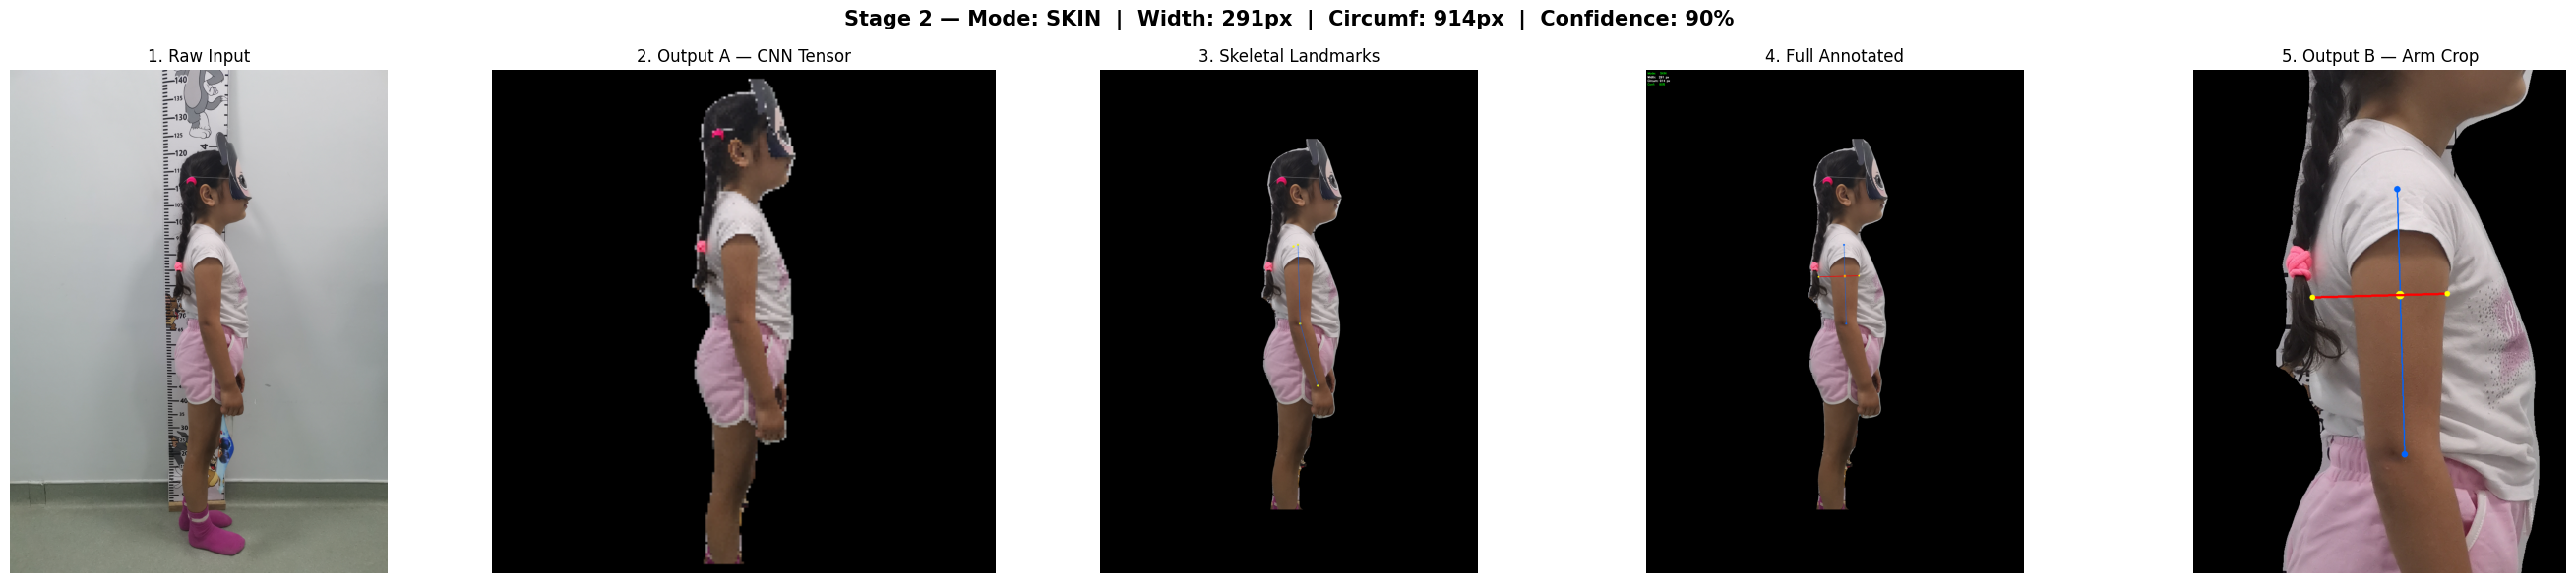


SKIN MODE SUMMARY
  True arm width     : 291 px
  Circumference      : 914 px
  Confidence         : 90%


In [14]:
# Change this path to any image from your dataset
TEST_IMAGE = r"C:\Users\cpans\OneDrive\Desktop\Nutrivision\ARAN\Data from anwar Sheikha\Female\child0008\child0008_04.jpg"

pipeline = NutriVisionStage2()
result   = pipeline.run_pipeline(TEST_IMAGE)

if result['mode'] != 'FAILED':
    m = result['measurement']

    fig, axes = plt.subplots(1, 5, figsize=(28, 6))
    fig.suptitle(
        f"Stage 2 — Mode: {m['mode']}  |  "
        f"Width: {int(m['width_px'])}px  |  "
        f"Circumf: {int(m['circumference_px'])}px  |  "
        f"Confidence: {int(m['confidence']*100)}%",
        fontsize=15, fontweight='bold'
    )

    axes[0].imshow(cv2.cvtColor(result['original'],       cv2.COLOR_BGR2RGB))
    axes[0].set_title("1. Raw Input",         fontsize=12)

    axes[1].imshow(cv2.cvtColor(result['cnn_tensor'],     cv2.COLOR_BGR2RGB))
    axes[1].set_title("2. Output A — CNN Tensor", fontsize=12)

    axes[2].imshow(cv2.cvtColor(result['landmark_vis'],   cv2.COLOR_BGR2RGB))
    axes[2].set_title("3. Skeletal Landmarks",    fontsize=12)

    axes[3].imshow(cv2.cvtColor(result['arm_vis_full'],   cv2.COLOR_BGR2RGB))
    axes[3].set_title("4. Full Annotated",        fontsize=12)

    axes[4].imshow(cv2.cvtColor(result['arm_vis_zoomed'], cv2.COLOR_BGR2RGB))
    axes[4].set_title("5. Output B — Arm Crop",   fontsize=12)

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    if m['mode'] == 'SLEEVE':
        lo, hi = m['correction_range']
        print(f"\nSLEEVE MODE SUMMARY")
        print(f"  Raw sleeve width   : {int(m['raw_sleeve_px'])} px")
        print(f"  Corrected width    : {int(m['width_px'])} px  (x{pipeline.SLEEVE_CORRECTION_CENTER})")
        print(f"  Error range        : {int(lo)} px  to  {int(hi)} px")
        print(f"  Circumference est  : {int(m['circumference_px'])} px")
        print(f"  Confidence         : {int(m['confidence']*100)}%")
        print(f"\n  NOTE: To convert px -> cm you need a reference scale")
        print(f"        (e.g. known height from ARAN CSV to calibrate px/cm ratio)")
    else:
        print(f"\nSKIN MODE SUMMARY")
        print(f"  True arm width     : {int(m['width_px'])} px")
        print(f"  Circumference      : {int(m['circumference_px'])} px")
        print(f"  Confidence         : {int(m['confidence']*100)}%")
else:
    print("Pipeline failed — check image path and that the child is fully visible")
